## Libraries

In [1]:
#get parameters
import sys
sys.path.append('..')
from src.grass_functions import*
# from project_info_editable import *

/opt/conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
###############folder structure
import pathlib as pl
import os
import re
#set project variables
Project_Area = 'nebraska_regression_stantec'
sr = '26852' #set to None if you want to use the DEM's original projection
res = '10m' #DEM resolution, options are '1m', '3m', '10m', '30m', 'OPR'
buffer = 2000 #buffer around the project area in native units
#buffer = 0 #set to 0 if you do not want to buffer the project area
Location = Project_Area+'_'+sr #initiate variable here
Mapset = 'PERMANENT' #always set to this

#standard folder structure parameters
data_dir = pl.Path(os.getcwd()).parent/'data'
vector_dir = data_dir/'Vectors'/Project_Area
raster_dir = data_dir/'Rasters'/Project_Area
if not os.path.exists(vector_dir):
    os.makedirs(vector_dir)
if not os.path.exists(raster_dir):
    os.makedirs(raster_dir)

In [3]:
#########input and output shapefiles from the code
# provide shapefile with polygons or point to wbd file
basins = vector_dir/'WBD_HUC10s.shp'
temp = gpd.read_file(basins)

In [4]:
### Initiate new grass session

## GRASSGIS Location and Mapsets
Location = Project_Area+'_'+sr
Mapset = 'PERMANENT'

initialize_grass_db(Location, Mapset, sr)

#### Remove existing files if needed

#remove old files if needed
#remove_grass_data(grass_maps,'None','vector') #all as 

Database Location Exists
Database Mapset Exists
None
{'GISDBASE': '/home/grassdata', 'LOCATION_NAME': 'nebraska_regression_stantec_26852', 'MAPSET': 'PERMANENT'}


Current GRASS GIS 7 environment:


In [5]:
huc10s = list(temp['huc10'])
huc10s.sort()

In [6]:
with open(data_dir/'progress.txt', 'r') as t:
    completed_hucs = t.readlines()[0]
completed_hucs_list = completed_hucs.split(',')

In [ ]:
#loop through the list provided from the shapefile
for aoi in huc10s:
    if aoi in completed_hucs_list:
        print(f'not rerunning it for {aoi}')
        continue
    print(f'working on {aoi}')
    ## Set variables analysis - this will need to change in order to run through the values in the shapefile.
    data_scale = 'HUC8' #other options HUC12, HUC10, HUC8 OR the field name of the source data to be split <-- case sensitive
    analysis_scale = 'HUC10'

    if data_scale.find('HUC') >= 0:
        huc_level = re.findall("[0-9]+",data_scale)[0]
        if huc_level == str(len(aoi)):
            select_data = aoi
        else:
            select_data = aoi[:int(huc_level)]
    to_headwaters = False #False if only interested in local huc area
    outlet_aois = False #False if you do not have predefined outlet locations of interest

    #dem info
    dem_base_name = 'state_dem' #for saving in grass
    aligned = False
    carved = True

    #if you'd like to clean up after yourself, set this to True
    auto_delete = False

    ### Watershed Parameters
    print(f'base data is {select_data}, analysis area is {aoi}')

    #provide shapefile with outlet points if outlet_aois is True - this is the output
    outlet_shp = vector_dir/f'outlets.geojson'
    basin_shp = vector_dir/f'basins.geojson'

    dem = f'{dem_base_name}_{select_data}'
    if aligned:
        dem +='_a'
    if carved:
        dem +='_b'
    accum = f'accum_{select_data}'
    drain_dir = f'drain_dir_{select_data}'
    r_basins = f'r_basins_{select_data}'
    v_basins = f'v_basins_{select_data}'
    sub_basins = f'subbasins_{select_data}'
    v_stream = f'stream_{select_data}'
    r_streams = f'r_streams_{select_data}'

    # #list all grass files
    grass_maps = list_existing_grass(print_it=False)
    if 'MASK@PERMANENT' in grass_maps['raster']:
        gs.run_command('r.mask',flags = 'r')
        
    #### Confirm DEM exists
    assert dem+"@PERMANENT" in grass_maps['raster'], 'Check that dem exists in GRASS'

    #### Import area of interest to GRASS
    #set region
    gs.run_command('g.region',raster = dem,align=dem)
    
    #prep area of interest
    aoi_path = vector_dir/f'aoi_{aoi}.geojson'
    temp.loc[temp[analysis_scale.lower()] == aoi].to_file(aoi_path, driver="GeoJSON")

    gs.run_command('v.import', input= aoi_path,  output= f'aoi_{aoi}')
    print('added aoi to grass')

    #### Buffer area of interest
    #add mask and reset region
    gs.run_command('v.buffer',input=f'aoi_{aoi}',output=f'buffer_{aoi}',distance = buffer)
    #mask outside cells
    grass_maps = list_existing_grass(print_it=False)
    if 'MASK@PERMANENT' in grass_maps['raster']:
        gs.run_command('r.mask',flags = 'r')
    gs.run_command('r.mask',vector = f'buffer_{aoi}',overwrite=True)
    gs.run_command('g.region',raster = dem,align=dem,zoom=dem)
    
    #outlets
    outlets = f'outlets_{aoi}'
    if outlet_aois:
        gs.run_command('v.import', input=  outlet_shp,  output= outlets)
    else:
        #get outlet point by identifying the highest accumulation value along the perimeter.
        gs.run_command('v.rast.stats', raster=accum, map=f'aoi_{aoi}',method='max',column='accum')
        max_accum = list(gs.parse_command('v.db.select', columns='accum_maximum',map = f'aoi_{aoi}',flags='c').keys())
        for outlet_accum in max_accum:
            
            gs.run_command('r.mapcalc',expression = f'r_{outlets} = if({accum} == {outlet_accum},{aoi},null())')
            
            gs.run_command('r.to.vect', input=f'r_{outlets}', output=outlets, type='point')

            
    #basin_relief
    gs.run_command('v.rast.stats', raster=dem, map=f'aoi_{aoi}',method='max',column='dem')
    gs.run_command('v.rast.stats', raster=dem, map=outlets,method='min',column='dem_outlet')
    

    
    #FOS
    gs.run_command('g.region',raster=dem)
    # if 'MASK@PERMANENT' in grass_maps['raster']:
    #     gs.run_command('r.mask',flags = 'r')
    # gs.run_command('r.mask',vector = f'aoi_{aoi}',overwrite=True)
    # gs.run_command('g.region',raster=dem,align=dem,zoom=dem)
    #set region better
    gs.run_command('r.mapcalc',expression = f'{r_streams}_{aoi} = {r_streams}')
    gs.run_command('r.mapcalc',expression = f'{drain_dir}_{aoi} = {drain_dir}')
    gs.run_command('g.region',raster =f'{r_streams}_{aoi}')
    if 'MASK@PERMANENT' in grass_maps['raster']:
        gs.run_command('r.mask',flags = 'r')
    gs.run_command('r.mask',vector = f'aoi_{aoi}',overwrite=True)
    gs.run_command('r.stream.order',stream_rast = f'{r_streams}_{aoi}',direction = f'{drain_dir}_{aoi}',strahler = f'r_stream_order_{aoi}',memory=10000)
    stats = gs.parse_command('r.stream.stats',stream_rast = f'r_stream_order_{aoi}',direction = f'{drain_dir}_{aoi}',elevation=dem,flags='o',memory=10000)
    num_fos = list(stats)[2].split(',')[1]
    gs.run_command('v.db.addcolumn',map=f'aoi_{aoi}',columns='FOS integer')
    gs.run_command('v.db.update',map=f'aoi_{aoi}',layer=1,column='FOS',value=int(num_fos))
    
    #MCS_FtpMia
    gs.run_command('r.stream.distance',stream_rast = f'{r_streams}_{aoi}', direction=f'{drain_dir}_{aoi}',method = 'downstream',distance= f'lfpds_{aoi}',flags='o',memory=10000)
    #reset mask to buffer
    gs.run_command('g.region',raster = dem)
    if 'MASK@PERMANENT' in grass_maps['raster']:
        gs.run_command('r.mask',flags = 'r')
    gs.run_command('r.mask',vector = f'buffer_{aoi}',overwrite=True)
    gs.run_command('g.region',raster = dem,align=dem,zoom=dem)
    max_dist = gs.parse_command('r.info',map=f'lfpds_{aoi}',flags='s')['max']
    gs.run_command('r.mapcalc',expression = f'lfpds_start_{aoi} = if(lfpds_{aoi} >= {float(max_dist)-.01},{aoi},null())')
    gs.run_command('r.to.vect', input=f'lfpds_start_{aoi}', output=f'v_lfpds_start_{aoi}', type='point')
    #extract only one path to run; choose first
    gs.run_command('v.extract',input=f'v_lfpds_start_{aoi}',cats='1',output=f'v_lfpds_start_op_{aoi}')
    gs.run_command('r.path',input=f'{drain_dir}_{aoi}',format='45degree',start_points=f'v_lfpds_start_op_{aoi}',vector_path=f'mcl_{aoi}')
    gs.run_command('v.segment',input=f'mcl_{aoi}',rules= data_dir/'rules.txt',output=f'mcl_p_{aoi}')
    gs.run_command('v.db.addtable',map=f'mcl_p_{aoi}')
    gs.run_command('v.rast.stats', raster=dem, map=f'mcl_p_{aoi}',method='max',column='elev')
    elevations = list(gs.parse_command('v.db.select', columns='elev_maximum',map = f'mcl_p_{aoi}',flags='c').keys())
    
    elevation_diff = float(elevations[0]) - float(elevations[1])
    assert elevation_diff >= 0,'something is wrong'
    #length in miles
    len_mi = (float(list(gs.parse_command('v.to.db',map=f'mcl_{aoi}',option='length',flags='p'))[1].split('|')[1])*0.75)/5280
    ft_mi = elevation_diff / len_mi
    gs.run_command('v.db.addcolumn',map=f'aoi_{aoi}',columns='MCL_Ft_pMi double precision')
    gs.run_command('v.db.update',map=f'aoi_{aoi}',layer=1,column='MCL_Ft_pMi',value=ft_mi)
    
    #### Plot to confirm

    gs.run_command('d.erase')
    gs.run_command('d.rast', map= dem)
    gs.run_command('d.vect', map= f'aoi_{aoi}',color='red',fill_color='None')
    gs.run_command('d.vect', map= outlets,color='black',fill_color='None')
    Image(filename="map.png")

    #### Export Outlets to Shp
    if aoi == huc10s[0]:
        gs.run_command('v.out.ogr',input=outlets,output = outlet_shp,output_layer='outlets',format='GeoJSON')
        gs.run_command('v.out.ogr',input=f'aoi_{aoi}',output = basin_shp,output_layer='basins',format='GeoJSON')
    else:
        #append
        gs.run_command('v.out.ogr',input=outlets,output = outlet_shp,output_layer='outlets',format='GeoJSON',flags='a')
        gs.run_command('v.out.ogr',input=f'aoi_{aoi}',output = basin_shp,output_layer='basins',format='GeoJSON',flags='a')
    
    #save progress
    with open(data_dir/'progress.txt','a') as prj:
        if aoi == huc10s[0]:
            prj.write(aoi)
        else:
            prj.write(','+aoi)
    gs.run_command('r.mask',flags = 'r')
    # END OF HUC10 RUN

not rerunning it for 1012010501
not rerunning it for 1012010502
not rerunning it for 1012010503
not rerunning it for 1012010504
not rerunning it for 1012010601
not rerunning it for 1012010602
not rerunning it for 1012010603
not rerunning it for 1012010604
not rerunning it for 1012010605
not rerunning it for 1012010701
not rerunning it for 1012010702
not rerunning it for 1012010703
not rerunning it for 1012010704
not rerunning it for 1012010705
not rerunning it for 1012010801
not rerunning it for 1012010802
not rerunning it for 1012010803
not rerunning it for 1012010901
not rerunning it for 1012010902
not rerunning it for 1012010903
not rerunning it for 1012010904
not rerunning it for 1012010905
not rerunning it for 1012010906
not rerunning it for 1012010907
not rerunning it for 1012010908
not rerunning it for 1012010909
not rerunning it for 1012010910
not rerunning it for 1012010911
not rerunning it for 1014020101
not rerunning it for 1014020102
not rerunning it for 1014020103
not reru

Raster MASK removed
/opt/conda/lib/python3.9/site-packages/geopandas/io/file.py:299: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,
Check if OGR layer <aoi_1020020202> contains polygons...
   0 100
Creating attribute table for layer <aoi_1020020202>...
Importing 1 features (OGR layer <aoi_1020020202>)...
   0 100
-----------------------------------------------------
Registering primitives...
-----------------------------------------------------
Cleaning polygons
-----------------------------------------------------
Breaking polygons...
Breaking polygons (pass 1: select break points)...
 100
Breaking polygons (pass 2: break at selected points)...
 100
-----------------------------------------------------
Removing duplicates...
 100
-----------------------------------------------------
Breaking boundaries...
   0 100
--------------------------------------------------

added aoi to grass


         overwritten
Buffering areas...
 100
Cleaning buffers...
Building parts of topology...
Building topology for vector map <buffer_1020020202@PERMANENT>...
Registering primitives...
Snapping boundaries...
Reading features...
Snap vertices Pass 1: select points
   0  50 100
Snap vertices Pass 2: assign anchor vertices
   4   9  14  19  24  29  34  39  44  49  54  59  64  69  74  79  84  89  94  99 100
Snap vertices Pass 3: snap to assigned points
   0  50 100
Breaking polygons...
Breaking polygons (pass 1: select break points)...
  50 100
Breaking polygons (pass 2: break at selected points)...
  50 100
Removing duplicates...
  50 100
Breaking boundaries...
   0  50 100
Removing duplicates...
  50 100
Cleaning boundaries at nodes
  50 100
Building topology for vector map <buffer_1020020202@PERMANENT>...
Building areas...
   0  50 100
Removing dangles...
  50 100
Removing bridges...
  50 100
Attaching islands...
Building topology for vector map <buffer_1020020202@PERMANENT>...
Attach

working on 1020020301
base data is 10200203, analysis area is 1020020301


Check if OGR layer <aoi_1020020301> contains polygons...
   0 100
Creating attribute table for layer <aoi_1020020301>...
Importing 1 features (OGR layer <aoi_1020020301>)...
   0 100
-----------------------------------------------------
Registering primitives...
-----------------------------------------------------
Cleaning polygons
-----------------------------------------------------
Breaking polygons...
Breaking polygons (pass 1: select break points)...
 100
Breaking polygons (pass 2: break at selected points)...
 100
-----------------------------------------------------
Removing duplicates...
 100
-----------------------------------------------------
Breaking boundaries...
   0 100
-----------------------------------------------------
Removing duplicates...
 100
-----------------------------------------------------
Cleaning boundaries at nodes...
 100
-----------------------------------------------------
Merging boundaries...
 100
---------------------------------------------------

added aoi to grass


Buffering areas...
 100
Cleaning buffers...
Building parts of topology...
Building topology for vector map <buffer_1020020301@PERMANENT>...
Registering primitives...
Snapping boundaries...
Reading features...
Snap vertices Pass 1: select points
   0 100
Snap vertices Pass 2: assign anchor vertices
   4   9  14  19  24  29  34  39  44  49  54  59  64  69  74  79  84  89  94  99 100
Snap vertices Pass 3: snap to assigned points
   0 100
Breaking polygons...
Breaking polygons (pass 1: select break points)...
 100
Breaking polygons (pass 2: break at selected points)...
 100
Removing duplicates...
 100
Breaking boundaries...
   0 100
Removing duplicates...
 100
Cleaning boundaries at nodes
 100
Building topology for vector map <buffer_1020020301@PERMANENT>...
Building areas...
   0 100
Removing dangles...
 100
Removing bridges...
 100
Attaching islands...
Building topology for vector map <buffer_1020020301@PERMANENT>...
Attaching islands...
   0 100
Calculating centroids for all areas...
  

In [ ]:
print('complete_loop_finished')

In [9]:
gs.run_command('r.mask',flags = 'r')
gs.run_command('g.region',raster = dem,align=dem,zoom=dem)

Raster MASK removed


0

   0   3   6   9  12  15  18  21  24  27  30  33  36  39  42  45  48  51  54  57  60  63  66  69  72  75  78  81  84  87  90  93  96  99 100
d.vect complete.
d.vect complete.


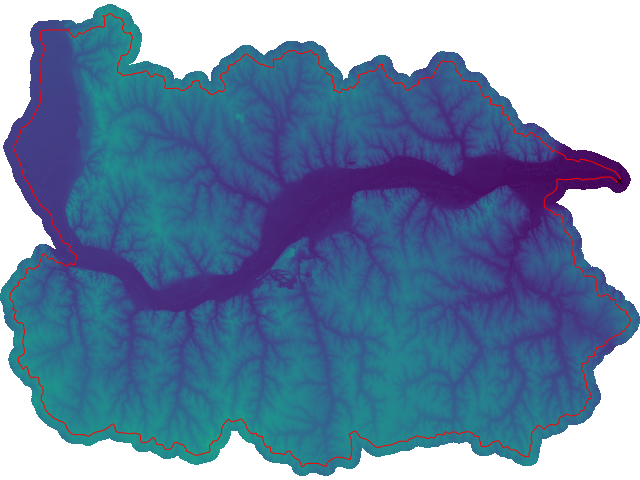

In [11]:
gs.run_command('d.erase')
gs.run_command('d.rast', map= dem)
gs.run_command('d.vect', map= f'aoi_{aoi}',color='red',fill_color='None')
gs.run_command('d.vect', map= outlets,color='black',fill_color='None')
Image(filename="map.png")

In [12]:
elevations[0]

'1151.38171386719'

In [13]:
elevations[1]

'965.226196289062'

In [14]:
elevation_diff = float(elevations[0]) - float(elevations[1])

In [15]:
elevation_diff

186.15551757812796

## Calculate Watershed Attributes and basin Delineation at Points

    reg = gs.parse_command('g.region', raster=dem, flags='pg', zoom=dem,align=dem)
    cell_size = float(reg.nsres)

    threshold = 25899 #cells

    gs.run_command('r.watershed', elevation=dem,threshold = threshold,accumulation=accum,drainage=drain_dir,basin=sub_basins,stream=r_streams,flags='sab')

    if outlet_aois:
        gs.run_command('r.stream.snap',input=outlets, 
                   output=f'{outlets}_moved',  
                   stream_rast=r_streams,
                   accumulation=accum, threshold = threshold, radius = 800,
                   memory = 4000)
        gs.run_command('r.stream.basins', dir=drain_dir,points = f'{outlets}_moved',basins=r_basins)
    else:
        gs.run_command('r.stream.basins', dir=drain_dir,stream_rast = r_streams,basins=r_basins,flags='l')

    print("Converting the delineated watershed rasters to vectors")
    gs.run_command('r.to.vect', input=r_basins, output= v_basins, type="area", flags='s')

    print("Get basin ID from the raster")
    basin_IDs = gs.parse_command('r.describe',map = r_basins, flags = '1n' )
    basin_list = [int(x) for x in [*basin_IDs]]

    gs.run_command('v.out.ogr',input=v_basins , output=vector_dir/f'basins_{select_data}.shp', format ='ESRI_Shapefile')

    ## Plot the Results

    os.environ['GRASS_RENDER_WIDTH'] ='1000' #the width of the image map (default is 640).
    os.environ['GRASS_RENDER_HEIGHT']='800' #the height of the image map (default is 480).
    gs.run_command('d.erase')
    gs.run_command('d.rast', map=sub_basins)
    gs.run_command('d.rast', map=r_streams)
    if outlet_aois:
        gs.run_command('d.vect', map=v_basins,color='black',fill_color='none')
        gs.run_command('d.vect', map=f'{outlets}_moved',color='green',fill_color='none')
    #gs.run_command('d.vect', map=v_stream,color='blue',fill_color='none')
    Image(filename="map.png")

    # exports

    out_rasts = [accum, drain_dir, sub_basins]
    for rast in out_rasts:
        gs.run_command('r.out.gdal', input= rast, output= raster_dir/f'{rast}.tif',createopt="BIGTIFF=YES,PROFILE=GeoTIFF,TFW=YES,COMPRESS=LZW",flags='f')
